In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("zuu crew scores.csv")
df = df[df['CourseName'] == 'Foundations of ML']
df["Passed"] = df["CapstoneScore"] > 50
del df['MemberName'], df['CourseName'], df['CapstoneScore']
df.head()

,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,Passed
0,3,79.9,43.7,2,0,62.8,5.0,False
1,2,76.8,95.6,6,0,87.4,2.7,True
2,3,96.6,75.9,8,0,98.4,2.8,True
4,2,83.2,24.0,6,0,41.8,4.2,False
7,3,86.5,88.0,5,0,23.9,1.3,True


In [4]:
Y = df['Passed'].values 
X = df.drop(columns=['Passed'])

In [5]:
Y

array([False,  True,  True, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True, False,  True, False,
       False,  True,  True, False, False,  True,  True, False, False,
       False,  True, False,  True, False, False,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
        True, False, False,  True,  True,  True, False, False,  True])

In [6]:
logr = LogisticRegression(max_iter=1000)
logr.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
Y_hat = logr.predict(X)
Y_hat

array([False,  True,  True, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True, False,  True, False,
       False,  True,  True, False, False,  True,  True, False, False,
       False,  True, False,  True, False, False,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
        True, False,  True,  True,  True,  True, False, False,  True])

In [11]:
""" 
P(Y=1/x)
"""

Y_proba = logr.predict_proba(X)
Y_proba = Y_proba[:, 1]
Y_proba

array([4.80678046e-01, 9.99999933e-01, 9.99987763e-01, 4.62904588e-04,
       9.99999476e-01, 9.99999870e-01, 2.03326805e-02, 9.96318362e-01,
       5.15141412e-02, 1.45083084e-01, 9.96286541e-01, 3.85410314e-04,
       6.77637098e-03, 9.02300748e-01, 9.81613671e-01, 5.81388729e-06,
       9.99999999e-01, 1.00602172e-04, 2.34262920e-01, 9.99999810e-01,
       9.87579126e-01, 4.88244335e-03, 1.85084191e-04, 9.99999933e-01,
       9.99999958e-01, 1.75484415e-02, 8.12598788e-03, 1.70408698e-03,
       5.04043867e-01, 6.49495022e-04, 9.99999996e-01, 5.56776809e-03,
       8.04668323e-06, 9.99926485e-01, 9.99948370e-01, 9.99750714e-01,
       3.09427146e-05, 2.28164803e-02, 9.17839092e-04, 9.99742421e-01,
       9.97212665e-01, 9.99549559e-01, 9.94920210e-01, 9.99990091e-01,
       5.33849352e-01, 9.10884672e-01, 7.23584531e-01, 7.08170083e-04,
       9.97529109e-01, 8.37252908e-04, 9.99950107e-01, 1.16566618e-02,
       7.72401502e-01, 9.99999945e-01, 9.99947446e-01, 9.99999930e-01,
      

In [12]:
def compute_confusion_matrix(Y, Y_hat):
    TP = np.sum((Y == 1) & (Y_hat == 1))
    FP = np.sum((Y == 0) & (Y_hat == 1))
    TN = np.sum((Y == 0) & (Y_hat == 0))
    FN = np.sum((Y == 1) & (Y_hat == 0))
    return np.array(
                    [
                    [TN, FP],
                    [FN, TP]
                    ],
                    dtype=int
                    )

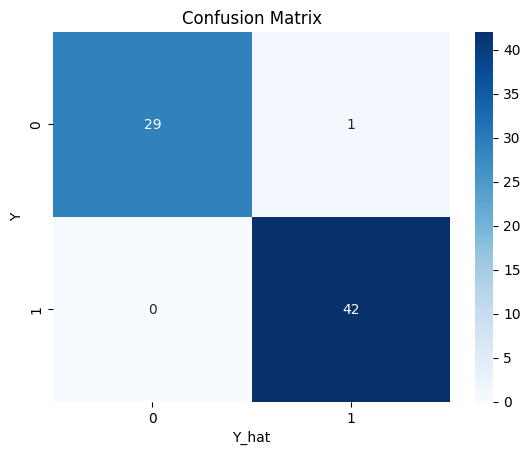

In [13]:
cm = compute_confusion_matrix(Y, Y_hat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Y_hat')
plt.ylabel('Y')
plt.title('Confusion Matrix')
plt.show()

In [14]:
def precision_score(cm):
    TP = cm[1,1]
    FP = cm[0,1]
    return TP / (TP + FP)

def recall_score(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP +FN)

def f1_score(cm):
    p = precision_score(cm)
    r = recall_score(cm) 
    return (2 * p * r) / (p + r)

def accuracy(cm):
    TP = cm[1,1]
    FP = cm[0,1]
    FN = cm[1,0]
    TN = cm[0,0]
    return (TP + TN) / (TP + TN + FP + FN)

In [15]:
cm = compute_confusion_matrix(Y, Y_hat) 
p = precision_score(cm)
r = recall_score(cm) 
f1 = f1_score(cm)
acc = accuracy(cm)

print(f"Precision : {p}")
print(f"Recall : {r}")
print(f"F1 Score : {f1}")
print(f"Accuracy : {acc}")

Precision : 0.9767441860465116
Recall : 1.0
F1 Score : 0.988235294117647
Accuracy : 0.9861111111111112


In [17]:
def roc_curve(Y, Y_proba):
    thresholds = np.linspace(0, 1, 200) 

    tpr_list = []
    fpr_list = []

    for t in thresholds:
        y_hat = (Y_proba >= t).astype(int)
        
        TP = np.sum((Y == 1) & (y_hat == 1))
        FP = np.sum((Y == 0) & (y_hat == 1))
        TN = np.sum((Y == 0) & (y_hat == 0))
        FN = np.sum((Y == 1) & (y_hat == 0))

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN)
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(tpr_list), np.array(fpr_list), np.array(thresholds)

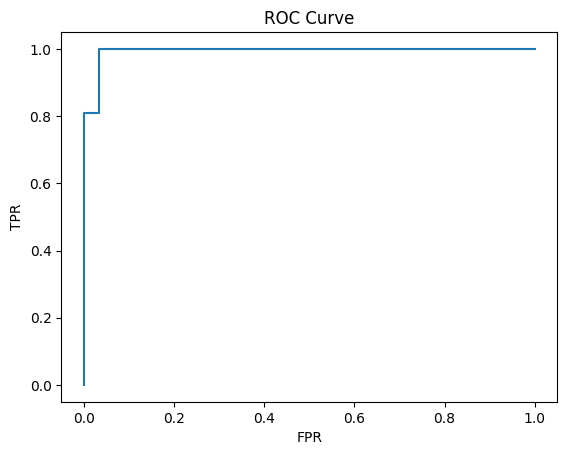

In [18]:
tpr, fpr, _ = roc_curve(Y, Y_proba)

plt.plot(fpr, tpr, label='LogReg')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

#### Homework ?

- How to compute AUC ? 